# HDB Spatial Models

This notebook explores the use of spatial models, specifically Spatial Error Model (SEM) section. It uses the same feature logic as the OLS setup while considering spatial weights

Steps:
1. Data preparation and feature definition follows that of OLS 
    - prepare_model_data()
    - define flat_controls, loc_controls, town_controls

2. Compute spatial diagnositics to determine Moran I's statistic to determine spatial autocorrelation significance.\
   Compute Robust LM-lag, and Robust LM-error tests to determine model specification (Spatial Error Model or Spatial Lag Model)
    - run_spatial_diagnostics()
    - compute_lm_tests()

3. Run Models 
    - run_ols_models ()
    - run_sem_models ()

It evaluates two SEM approaches:
1. Stepwise / consecutive models that mirror the staged OLS specifications.
2. Fully controlled single-variable SEMs for `near_schools_1km`, `near_tier1_1km`, `near_schools_2km`, and `near_tier1_2km`.


In [2]:
from pathlib import Path
import os
import warnings

import geopandas as gpd
import numpy as np
import pandas as pd
import statsmodels.api as sm
from esda.moran import Moran
from IPython.display import display
from libpysal.weights import KNN
from scipy.stats import chi2
from spreg import GM_Error
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

warnings.filterwarnings("ignore")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mpl-cache"))

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

DATA_PATH = "cleaned_datasets/resale_with_all_features_dummies.parquet"
MAX_ROWS = 3000
RANDOM_STATE = 42
K_NEIGHBORS = 8


### 1. Data prep for OLS and SEM 

In [3]:
def parse_remaining_lease(val):
    """
    Parse remaining_lease to numeric.
    """
    val = str(val).strip()
    if "year" in val:
        parts = val.split()
        years = int(parts[0])
        months = int(parts[2]) if len(parts) >= 4 else 0
        return years + months / 12
    return float(val)


def prepare_model_data():
    df = gpd.read_parquet(DATA_PATH).copy()

    # 1. Log-transform target 
    df["remaining_lease_numeric"] = df["remaining_lease"].apply(parse_remaining_lease)
    df["log_resale_price"] = np.log(df["resale_price"])

    # 2. Cap walking_dist_mall_m outlier 
    # max of 20,885m is a geocoding error
    cap_mall = df["walking_dist_mall_m"].quantile(0.99)
    n_capped = (df["walking_dist_mall_m"] > cap_mall).sum()
    df["walking_dist_mall_m"] = df["walking_dist_mall_m"].clip(upper=cap_mall)  

    # 3. Treatment variable
    # binary: 1 if within 1km of Tier-1 school (MOE Phase 2B cutoff)
    df["near_tier1_1km"] = (df["num_tier1_schools_1km"] >= 1).astype(int)
    df["near_schools_1km"] = (df["num_schools_1km"] >= 1).astype(int)
    df["near_schools_2km"] = (df["num_schools_2km"] >= 1).astype(int)
    df["near_tier1_2km"] = (df["nearest_tier1_primary_school_dist_m"] <= 2000).astype(int)

    # 4. Drop non-features
    df = df.drop(
        columns=["month", "year", "remaining_lease", "resale_price"],
        errors="ignore",
    ).copy()

    # 5. Create spatial weights
    # specific for spatial models 
    coords = np.column_stack([df.geometry.x.values, df.geometry.y.values])
    w = KNN.from_array(coords, k=K_NEIGHBORS)
    w.transform = "r"

    return df, w

# Define features
flat_controls = [
    "floor_area_sqm",
    "remaining_lease_numeric",
    "flat_type_2 ROOM",
    "flat_type_3 ROOM",
    "flat_type_4 ROOM",
    "flat_type_5 ROOM",
    "flat_type_EXECUTIVE",
    "storey_range_04 TO 06",
    "storey_range_07 TO 09",
    "storey_range_10 TO 12",
    "storey_range_13 TO 15",
    "storey_range_16 TO 18",
    "storey_range_19 TO 21",
    "storey_range_22 TO 24",
    "storey_range_25 TO 27",
    "storey_range_28 TO 30",
    "storey_range_31 TO 33",
    "storey_range_34 TO 36",
    "storey_range_37 TO 39",
    "storey_range_40 TO 42",
    "storey_range_43 TO 45",
    "storey_range_46 TO 48",
    "storey_range_49 TO 51",
    "flat_model_3Gen",
    "flat_model_Adjoined flat",
    "flat_model_Apartment",
    "flat_model_DBSS",
    "flat_model_Improved",
    "flat_model_Improved-Maisonette",
    "flat_model_Maisonette",
    "flat_model_Model A",
    "flat_model_Model A-Maisonette",
    "flat_model_Model A2",
    "flat_model_New Generation",
    "flat_model_Premium Apartment",
    "flat_model_Premium Apartment Loft",
    "flat_model_Premium Maisonette",
    "flat_model_Simplified",
    "flat_model_Standard",
    "flat_model_Terrace",
    "flat_model_Type S1",
    "flat_model_Type S2",
]

loc_controls = [
    "walking_dist_mrt_m",
    "walking_dist_busstop_m",
    "walking_dist_hawker_m",
    "walking_dist_mall_m",
    "dist_cbd_m",
]

town_controls = [
    "town_BEDOK",
    "town_BISHAN",
    "town_BUKIT BATOK",
    "town_BUKIT MERAH",
    "town_BUKIT PANJANG",
    "town_BUKIT TIMAH",
    "town_CENTRAL AREA",
    "town_CHOA CHU KANG",
    "town_CLEMENTI",
    "town_GEYLANG",
    "town_HOUGANG",
    "town_JURONG EAST",
    "town_JURONG WEST",
    "town_KALLANG/WHAMPOA",
    "town_MARINE PARADE",
    "town_PASIR RIS",
    "town_PUNGGOL",
    "town_QUEENSTOWN",
    "town_SEMBAWANG",
    "town_SENGKANG",
    "town_SERANGOON",
    "town_TAMPINES",
    "town_TOA PAYOH",
    "town_WOODLANDS",
    "town_YISHUN",
]

df_model, w = prepare_model_data()
y_series = df_model["log_resale_price"].astype(float)

print(f"Rows used for OLS and SEM: {len(df_model):,}")
print(f"KNN neighbors: {K_NEIGHBORS}")


Rows used for OLS and SEM: 180,003
KNN neighbors: 8


### 2. Helper functions to print results

In [4]:
def significance_label(p_value):
    if pd.isna(p_value):
        return "n.s."
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return "n.s."


def print_results_table(df, title, r2_col):
    print("=" * 120)
    print(f"{title:^120}")
    print("=" * 120)
    header = (
        f"{'Model Spec':<36} {'Variable':<20} {'Beta':>10} {'p-val':>10} "
        f"{'Sig':>6} {'% Effect':>12} {r2_col:>12} {'Lambda':>10}"
    )
    print(header)
    print("-" * 120)

    for _, row in df.iterrows():
        print(
            f"{row['Model Spec']:<36} {row['Variable']:<20} "
            f"{row['Beta']:>10.4f} {row['p-val']:>10.4f} {row['Sig']:>6} "
            f"{row['% Effect']:>+11.2f}% {row[r2_col]:>12.4f} {row['Lambda']:>10.4f}"
        )

    print("-" * 120)


### 3. Functions to get results of LM tests

In [5]:
def compute_lm_tests(ols_model, X_with_constant, y_series, w):
    """
    Compute Robust LM-lag, and Robust LM-error tests based on the OLS model residuals and spatial weights.
    """
    residuals = ols_model.resid.to_numpy().reshape(-1, 1)
    fitted = ols_model.fittedvalues.to_numpy().reshape(-1, 1)
    y_array = y_series.to_numpy().reshape(-1, 1)
    x_array = X_with_constant.to_numpy()
    n = len(y_array)
    xtxi = np.asarray(ols_model.normalized_cov_params)
    sigma2_n = ((residuals.T @ residuals) / n).item()

    w_sparse = w.sparse
    wu = w_sparse @ residuals
    utwu_ds = ((residuals.T @ wu) / sigma2_n).item()
    utwy_ds = ((residuals.T @ (w_sparse @ y_array)) / sigma2_n).item()
    t_term = float(np.sum((((w_sparse.T + w_sparse) @ w_sparse).diagonal())))

    wxb = w_sparse @ fitted
    xwxb = x_array.T @ wxb
    j_num = (wxb.T @ wxb) - (xwxb.T @ xtxi @ xwxb) + (t_term * sigma2_n)
    j_term = (j_num / (n * sigma2_n)).item()

    robust_lm_lag = float(((utwy_ds - utwu_ds) ** 2) / ((n * j_term) - t_term))
    robust_lm_error = float(
        ((utwu_ds - ((t_term * utwy_ds) / (n * j_term))) ** 2)
        / (t_term * (1.0 - (t_term / (n * j_term))))
    )

    return pd.DataFrame(
        [
            {
                "test": "Robust LM-lag",
                "statistic": robust_lm_lag,
                "p_value": chi2.sf(robust_lm_lag, 1),
            },
            {
                "test": "Robust LM-error",
                "statistic": robust_lm_error,
                "p_value": chi2.sf(robust_lm_error, 1),
            },
        ]
    )


def run_spatial_diagnostics(ols_objects, w):
    """
    Run spatial diagnostics for each OLS model, including Moran's I and Robust LM tests, 
    to determine preferred spatial model (SEM vs SLM).

    1. Calculates Moran's I, a classic test for general spatial autocorrelation. 

    2. Process multiple models at once by comparing "Robust LM-lag" vs. "Robust LM-error" statistics. 
       Whichever is higher becomes the "Preferred Spatial Model" (SEM vs. SLM).
    """
    diagnostics = []
    preferred_counts = {"SEM": 0, "SLM": 0, "Tie": 0}

    for model_name, model_parts in ols_objects.items():
        ols_model = model_parts["ols_model"]
        X_with_constant = model_parts["X_with_constant_model"]
        y_series_model = model_parts["y_series_model"]

        resids = ols_model.resid.to_numpy().flatten()
        moran = Moran(resids, w, permutations=0)
        lm_df = compute_lm_tests(ols_model, X_with_constant, y_series_model, w)

        robust_lag = lm_df.loc[lm_df["test"] == "Robust LM-lag", "statistic"].iloc[0]
        robust_error = lm_df.loc[lm_df["test"] == "Robust LM-error", "statistic"].iloc[0]

        if robust_error > robust_lag:
            preferred = "SEM"
        elif robust_lag > robust_error:
            preferred = "SLM"
        else:
            preferred = "Tie"

        preferred_counts[preferred] += 1

        diagnostics.append(
            {
                "Model": model_name,
                "Moran's I": moran.I,
                "Moran p-val": moran.p_norm,
                "Robust LM-lag": robust_lag,
                "LM-lag p-val": lm_df.loc[lm_df["test"] == "Robust LM-lag", "p_value"].iloc[0],
                "Robust LM-error": robust_error,
                "LM-error p-val": lm_df.loc[lm_df["test"] == "Robust LM-error", "p_value"].iloc[0],
                "Preferred Spatial Model": preferred,
            }
        )

    diagnostics_df = pd.DataFrame(diagnostics)
    return diagnostics_df, preferred_counts

### 3. Models 
- OLS 
    - OLS is needed as the residuals will be used in Moran I's test 
    - The results are used to determine spatial model specification
- SEM

In [ ]:
def run_ols_models(df, y_series, model_var_dict):
    """
    Run OLS regressions for each model specification defined in model_var_dict.
    Store OLS model objects and results for each specification.
    """
    ols_objects = {}
    results = []

    for model_label, school_vars in model_var_dict.items():
        feature_cols = get_feature_cols(model_label, school_vars)
        X = sm.add_constant(df[feature_cols].astype(float), has_constant="add")
        mod = sm.OLS(y_series, X).fit(cov_type="HC3")

        ols_objects[model_label] = {
            "ols_model": mod,
            "X_with_constant_model": X,
            "y_series_model": y_series,
            "feature_cols": feature_cols,
        }

        for var in school_vars:
            beta = mod.params[var]
            pval = mod.pvalues[var]
            results.append(
                {
                    "Model Spec": model_label,
                    "Variable": var,
                    "Beta": beta,
                    "p-val": pval,
                    "Sig": significance_label(pval),
                    "% Effect": (np.exp(beta) - 1) * 100,
                    "Adj. R2": mod.rsquared_adj,
                    "N": int(mod.nobs),
                }
            )

    return pd.DataFrame(results), ols_objects


def run_sem_models(df, y_series, w, model_var_dict):
    results = []

    for model_label, school_vars in model_var_dict.items():
        feature_cols = get_feature_cols(model_label, school_vars)
        X = df[feature_cols].astype(float)
        y_np = y_series.to_numpy().reshape(-1, 1)

        sem_model = GM_Error(
            y_np,
            X.to_numpy(),
            w=w,
            name_x=feature_cols,
            name_y="log_resale_price",
        )

        beta_by_name = dict(zip(sem_model.name_x, np.asarray(sem_model.betas).reshape(-1)))
        se_by_name = dict(zip(sem_model.name_x, sem_model.std_err))
        pval_by_name = dict(
            zip(
                sem_model.name_x[:-1],
                [stat[1] for stat in sem_model.z_stat],
            )
        )

        lambda_value = float(np.asarray(sem_model.betas).reshape(-1)[-1])

        for var in school_vars:
            beta = beta_by_name[var]
            se = se_by_name.get(var, np.nan)
            pval = pval_by_name.get(var, np.nan)
            results.append(
                {
                    "Model Spec": model_label,
                    "Variable": var,
                    "Beta": beta,
                    "SE": se,
                    "p-val": pval,
                    "Sig": significance_label(pval),
                    "% Effect": (np.exp(beta) - 1) * 100,
                    "Pseudo R2": getattr(sem_model, "pr2", np.nan), # pseudo R2 for SEM as it uses maximum likelihood, not least squares
                    "Lambda": lambda_value,
                    "N": int(sem_model.n),
                }
            )

    return pd.DataFrame(results)


# helper function to determine feature columns based on model specification   
def get_feature_cols(model_label, school_vars):
    """
    Determine feature columns based on model specification.
    """
    if "baseline" in model_label.lower():
        return school_vars
    if "flat controls" in model_label.lower():
        return flat_controls + school_vars
    if "location controls" in model_label.lower():
        return flat_controls + loc_controls + school_vars
    return flat_controls + loc_controls + town_controls + school_vars

## Approach 1: Stepwise / Consecutive SEM

This approach mirrors  staged OLS logic so the SEM results can be compared model by model.


### 1. Stepwise approach for OLS 

In [ ]:
STEPWISE_MODEL_VAR = {
    "Model 1 (1km) baseline": ["near_tier1_1km"],
    "Model 2 (1km) add flat controls": ["near_tier1_1km"],
    "Model 3 (1km) add location controls": ["near_tier1_1km"],
    "Model 4 (1km) add town controls": ["near_tier1_1km"],
    "Model 5 (1km) add school controls": ["near_schools_1km", "near_tier1_1km"],
    "Model 1 (2km) baseline": ["near_tier1_2km"],
    "Model 2 (2km) add flat controls": ["near_tier1_2km"],
    "Model 3 (2km) add location controls": ["near_tier1_2km"],
    "Model 4 (2km) add town controls": ["near_tier1_2km"],
    "Model 5 (2km) add school controls": ["near_schools_2km", "near_tier1_2km"],
    "Model 5 (only near school 1km)": ["near_schools_1km"],
    "Model 6 (only near school 2km)": ["near_schools_2km"],
}

ols_stepwise_results, ols_stepwise_objects = run_ols_models(df_model, y_series, STEPWISE_MODEL_VAR)
stepwise_diagnostics_df, stepwise_preference_counts = run_spatial_diagnostics(ols_stepwise_objects, w)

display(ols_stepwise_results)
display(stepwise_diagnostics_df)
print("Preferred model counts:", stepwise_preference_counts)
# moran's I is significant across all specifications, indicating spatial autocorrelation in OLS residuals


,Model Spec,Variable,Beta,p-val,Sig,% Effect,Adj. R2,N
0,Model 1 (1km) baseline,near_tier1_1km,0.060099,0.000000,***,6.194160,0.005597,180003
1,Model 2 (1km) add flat controls,near_tier1_1km,0.122299,0.000000,***,13.009176,0.770152,180003
2,Model 3 (1km) add location controls,near_tier1_1km,0.031928,0.000000,***,3.244321,0.889099,180003
3,Model 4 (1km) add town controls,near_tier1_1km,0.000348,0.617260,n.s.,0.034807,0.925435,180003
4,Model 5 (1km) add school controls,near_schools_1km,-0.054646,0.000000,***,-5.317992,0.926171,180003
5,Model 5 (1km) add school controls,near_tier1_1km,0.004545,0.000000,***,0.455567,0.926171,180003
6,Model 1 (2km) baseline,near_tier1_2km,0.021038,0.000000,***,2.126050,0.001069,180003
7,Model 2 (2km) add flat controls,near_tier1_2km,0.157385,0.000000,***,17.044624,0.797894,180003
8,Model 3 (2km) add location controls,near_tier1_2km,0.033101,0.000000,***,3.365494,0.889342,180003
9,Model 4 (2km) add town controls,near_tier1_2km,0.018461,0.000000,***,1.863248,0.925572,180003


,Model,Moran's I,Moran p-val,Robust LM-lag,LM-lag p-val,Robust LM-error,LM-error p-val,Preferred Spatial Model
0,Model 1 (1km) baseline,0.825154,0.000000,0.094684,0.758305,6.033988,0.014033,SEM
1,Model 2 (1km) add flat controls,0.792694,0.000000,"2,117.646577",0.000000,"418,894.545781",0.000000,SEM
2,Model 3 (1km) add location controls,0.672587,0.000000,806.196096,0.000000,"369,374.674024",0.000000,SEM
3,Model 4 (1km) add town controls,0.528207,0.000000,872.267323,0.000000,"239,024.076591",0.000000,SEM
4,Model 5 (1km) add school controls,0.523412,0.000000,942.124461,0.000000,"234,601.650793",0.000000,SEM
5,Model 1 (2km) baseline,0.825915,0.000000,0.217563,0.640903,0.350799,0.553661,SEM
6,Model 2 (2km) add flat controls,0.775318,0.000000,"2,235.452124",0.000000,"418,857.594937",0.000000,SEM
7,Model 3 (2km) add location controls,0.670848,0.000000,901.824068,0.000000,"367,103.932373",0.000000,SEM
8,Model 4 (2km) add town controls,0.527132,0.000000,888.959860,0.000000,"238,035.079949",0.000000,SEM
9,Model 5 (2km) add school controls,0.522014,0.000000,936.849651,0.000000,"233,485.963038",0.000000,SEM


Preferred model counts: {'SEM': 12, 'SLM': 0, 'Tie': 0}


### 1.1 Stepwise results from OLS
- Moran I's value is moderately high, with all values > 0.52
- For all models, Robust LM-error > Robust LM-lag, so preferred spatial model is SEM

### 2. Stepwise approach for SEM 

In [ ]:
sem_stepwise_results = run_sem_models(df_model, y_series, w, STEPWISE_MODEL_VAR)
print_results_table(
    sem_stepwise_results,
    title="SPATIAL ERROR MODEL (SEM): STEPWISE / CONSECUTIVE APPROACH",
    r2_col="Pseudo R2",
)

# results are very similar to OLS
# lambda is moderately high (0.5-0.8) across all specifications, indicating spatial dependence in the error term
# but because coefficients and significance levels are similar to OLS, the spatial dependence is not correlated to regressors, so do not bias OLS coefficients

                               SPATIAL ERROR MODEL (SEM): STEPWISE / CONSECUTIVE APPROACH                               
Model Spec                           Variable                   Beta      p-val    Sig     % Effect    Pseudo R2     Lambda
------------------------------------------------------------------------------------------------------------------------
Model 1 (1km) baseline               near_tier1_1km           0.0594     0.0000    ***       +6.12%       0.0056     0.8624
Model 2 (1km) add flat controls      near_tier1_1km           0.1245     0.0000    ***      +13.26%       0.7447     0.8408
Model 3 (1km) add location controls  near_tier1_1km           0.0300     0.0000    ***       +3.05%       0.8810     0.7820
Model 4 (1km) add town controls      near_tier1_1km           0.0019     0.2682   n.s.       +0.19%       0.9215     0.7106
Model 5 (1km) add school controls    near_schools_1km        -0.0506     0.0000    ***       -4.93%       0.9223     0.7080
Model 5 (1km) 

### 2.1 Plot SEM coefficient for near_tier1 Effect across models

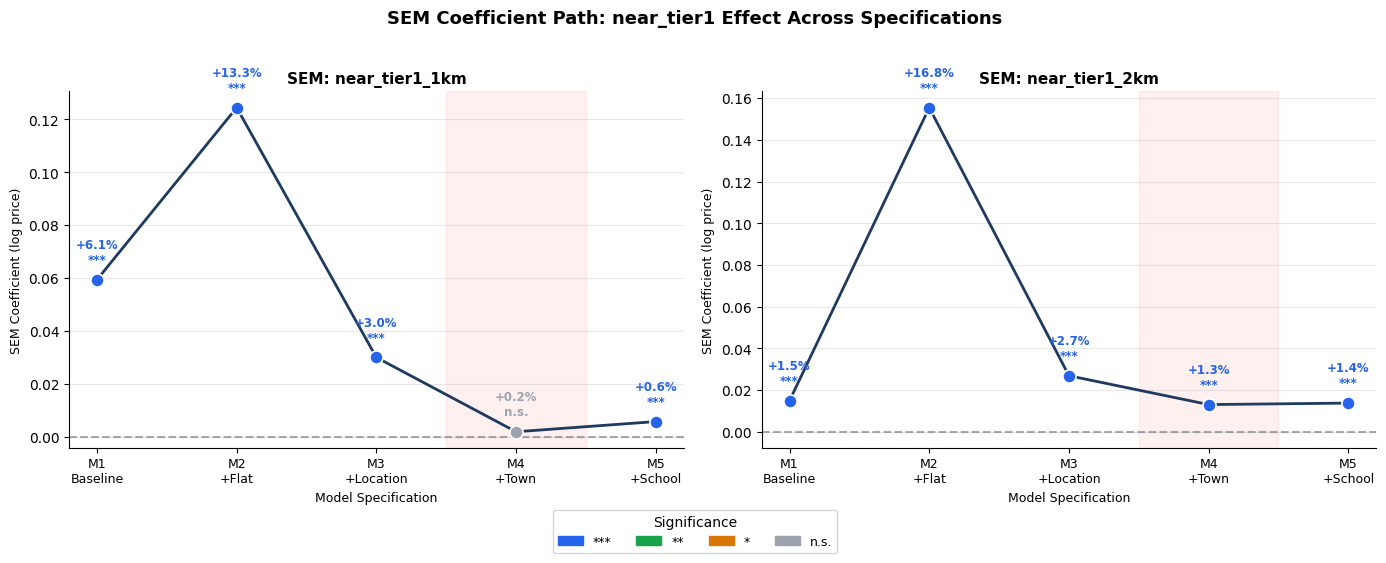

In [9]:
def build_coef_path(results_df, band):
    """Dynamically pulls beta, se, sig from results dict for a given band (1km or 2km)."""
    specs = [
        f"Model 1 ({band}) baseline",
        f"Model 2 ({band}) add flat controls",
        f"Model 3 ({band}) add location controls",
        f"Model 4 ({band}) add town controls",
        f"Model 5 ({band}) add school controls",
    ]
    var = f"near_tier1_{band}"

    beta, sig = [], []

    for s in specs:
        row = results_df[
            (results_df["Model Spec"] == s) &
            (results_df["Variable"] == var)
        ]

        if row.empty:
            beta.append(np.nan)
            sig.append("n.s.")
        else:
            beta.append(row["Beta"].values[0])
            sig.append(row["Sig"].values[0])

    return {
        "labels": ["M1\nBaseline", "M2\n+Flat", "M3\n+Location", "M4\n+Town", "M5\n+School"],
        "beta": beta,
        "sig": sig,
    }

coef_path = {
    "1km": build_coef_path(sem_stepwise_results, "1km"),
    "2km": build_coef_path(sem_stepwise_results, "2km"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("SEM Coefficient Path: near_tier1 Effect Across Specifications",
             fontsize=13, fontweight="bold", y=1.02)

colors = {"***": "#2563eb", "**": "#16a34a", "*": "#d97706", "n.s.": "#9ca3af"}
band_labels = ["1km", "2km"]

for ax, band in zip(axes, band_labels):
    d = coef_path[band]
    x = np.arange(len(d["labels"]))
    betas = np.array(d["beta"])

    # line
    ax.plot(x, betas, color="#1e3a5f", linewidth=2, zorder=3)

    # dots coloured by significance
    for i, (b, sig) in enumerate(zip(betas, d["sig"])):
        ax.scatter(i, b, color=colors[sig], s=90, zorder=4,
                   edgecolors="white", linewidth=1.2)

        ax.annotate(f"{(np.exp(b)-1)*100:+.1f}%\n{sig}",
                    xy=(i, b), xytext=(0, 12),
                    textcoords="offset points",
                    ha="center", fontsize=8.5,
                    color=colors[sig], fontweight="bold")

    ax.axhline(0, color="#6b7280", linestyle="--", alpha=0.6)

    # highlight town FE step
    ax.axvspan(2.5, 3.5, alpha=0.06, color="red")

    ax.set_xticks(x)
    ax.set_xticklabels(d["labels"], fontsize=9)
    ax.set_title(f"SEM: near_tier1_{band}", fontsize=11, fontweight="bold")
    ax.set_ylabel("SEM Coefficient (log price)", fontsize=9)
    ax.set_xlabel("Model Specification", fontsize=9)

    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

# legend
sig_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
fig.legend(handles=sig_patches, title="Significance",
           loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.tight_layout()
plt.show()

## Approach 2: Fully Controlled Single-Variable SEM

This approach keeps the full control set fixed and tests the four school variables one at a time.


### 1. Fully controlled single-variable approach for OLS 

In [10]:
DIRECT_TEST_MODEL_VAR = {
    "Full controls + near_schools_1km": ["near_schools_1km"],
    "Full controls + near_tier1_1km": ["near_tier1_1km"],
    "Full controls + near_schools_2km": ["near_schools_2km"],
    "Full controls + near_tier1_2km": ["near_tier1_2km"],
}

ols_direct_results, ols_direct_objects = run_ols_models(df_model, y_series, DIRECT_TEST_MODEL_VAR)
direct_diagnostics_df, direct_preference_counts = run_spatial_diagnostics(ols_direct_objects, w)

display(direct_diagnostics_df)
print("Preferred model counts:", direct_preference_counts)


,Model,Moran's I,Moran p-val,Robust LM-lag,LM-lag p-val,Robust LM-error,LM-error p-val,Preferred Spatial Model
0,Full controls + near_schools_1km,0.523508,0.000000,949.173833,0.000000,"234,669.398806",0.000000,SEM
1,Full controls + near_tier1_1km,0.528207,0.000000,872.267323,0.000000,"239,024.076591",0.000000,SEM
2,Full controls + near_schools_2km,0.523181,0.000000,918.923953,0.000000,"234,566.102404",0.000000,SEM
3,Full controls + near_tier1_2km,0.527132,0.000000,888.959860,0.000000,"238,035.079949",0.000000,SEM


Preferred model counts: {'SEM': 4, 'SLM': 0, 'Tie': 0}


### 2. Fully controlled single-variable approach for SEM 

In [11]:
sem_direct_results = run_sem_models(df_model, y_series, w, DIRECT_TEST_MODEL_VAR)
print_results_table(
    sem_direct_results,
    title="SPATIAL ERROR MODEL (SEM): FULL-CONTROL SINGLE-VARIABLE TESTS",
    r2_col="Pseudo R2",
)

                             SPATIAL ERROR MODEL (SEM): FULL-CONTROL SINGLE-VARIABLE TESTS                              
Model Spec                           Variable                   Beta      p-val    Sig     % Effect    Pseudo R2     Lambda
------------------------------------------------------------------------------------------------------------------------
Full controls + near_schools_1km     near_schools_1km        -0.0490     0.0000    ***       -4.78%       0.9223     0.7080
Full controls + near_tier1_1km       near_tier1_1km           0.0019     0.2682   n.s.       +0.19%       0.9215     0.7106
Full controls + near_schools_2km     near_schools_2km        -0.6823     0.0000    ***      -49.45%       0.9224     0.7077
Full controls + near_tier1_2km       near_tier1_2km           0.0130     0.0000    ***       +1.31%       0.9216     0.7100
------------------------------------------------------------------------------------------------------------------------
